In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import scipy.stats as stats
from scipy.stats import chi2, norm, t

from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set(style="whitegrid")
np.random.seed(42)
title_font = 18
labels_font = 16
text_font = 14
tick_font = 12
images_dir = "images/evaluation_4"
os.makedirs(images_dir, exist_ok=True)

# How Good is My Model? Part 4

This notebook supports [this](https://afnan-sultan.github.io/posts/2025/11/evaluation4/) blog post by plotting the different plots shown in it.

This notebook guides one through:

1. Checking the normality assumption of test set residual sample.
2. Constructing best and worst case scenarios behavior for a model based on normality assumption and confidence interval.
3. Explore a crocky visualization of data vs representation.
4. Explore the worldview of different models and see when they fit the representation and when they fail.
5. Check the homoscedasticity of a model to inspect possible biases.
6. Simple inspection of feature-target relationship.
7. Inspecting features to make sure they are in the correct format for the model we are training.
8. Understand the power of listening to different models instead of comparing them against each other.

TL;DR
![image](images/evaluation_4/sanity_flow.png)

---

# 0. Recalling last post

The below few cells are copied from the last notebook. We simply
1. Load a dataset
2. Featurize it using the RDKit descriptors
3. Split data into 80:20 train-test splits
4. Training a random forest (RF) model

In [2]:
DATASET_NAME = 'AZ'  # 'AZ' or 'Biogen'
DATASET_PATHS = {
    'AZ': 'data/aqueous_solubility/by_source/solubility_az.csv',
    'Biogen': 'data/aqueous_solubility/by_source/solubility_biogen.csv'
}

df = pd.read_csv(DATASET_PATHS[DATASET_NAME])
print(f"Loaded {DATASET_NAME} dataset with {len(df)} entries.")

Loaded AZ dataset with 1763 entries.


In [3]:
smiles_all = df['SMILES']
labels_all = df['LogS']
test_set_ratio = 0.2
smiles_train, smiles_test, y_train, y_test = train_test_split(
    smiles_all, labels_all, test_size=test_set_ratio, random_state=42
)

In [4]:
def featurize_rdkit_desc_split(smiles_train, smiles_test):
    # 1. Get descriptor names, exclude Ipc
    descriptor_names = [d[0] for d in Descriptors._descList if d[0] != 'Ipc']
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

    # 2. Featurize training set
    features_train, train_idx = [], []
    for i, smi in enumerate(smiles_train):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            features_train.append(calc.CalcDescriptors(mol))
            train_idx.append(i)
    X_train = pd.DataFrame(features_train, columns=descriptor_names)

    # 3. Drop zero-variance features (only from train)
    non_zero_var_cols = X_train.loc[:, X_train.std() > 0].columns
    X_train = X_train[non_zero_var_cols]

    # 4. Featurize test set, keeping only same columns
    features_test, test_idx = [], []
    for i, smi in enumerate(smiles_test):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            desc = calc.CalcDescriptors(mol)
            features_test.append(desc)
            test_idx.append(i)
    X_test_full = pd.DataFrame(features_test, columns=descriptor_names)

    # 5. Filter test features to keep only training-set features
    X_test = X_test_full[non_zero_var_cols]

    return X_train.reset_index(drop=True), train_idx, X_test.reset_index(drop=True), test_idx

X_train, train_idx, X_test, test_idx = featurize_rdkit_desc_split(smiles_train, smiles_test)

y_train = y_train.iloc[train_idx].reset_index(drop=True)
y_test  = y_test.iloc[test_idx].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1410, 193)
X_test shape: (353, 193)


In [5]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# 4) Predictions
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
residuals_test = y_pred_test - y_test

# 1. Checking normality

A test set of 353 molecules is considered a sample coming from a distribution. In the blog, one can see that a sample can hint to the distribution family it comes from. I concluded that the true distribution is normal, and therefore, I am performing a normality check on my sample using the `Q-Q plot`. This plot aligns the quantiles of my distribution to the quantiles of a standard normal distribution. If they align against a diagonal line, then bothe distributions are the same.

In [6]:
def plot_residual_distribution(
    residuals_or_dict,
    title='Residual Diagnostics',
    savepath=None,
    annotate=True,
    sharex=True,
    sharey=False,
    figsize_single=(12, 5),
    row_height=5,
    show=True,
):
    """
    Residual diagnostics:
      - For a single residual array -> returns a 1x2 figure (KDE, Q–Q).
      - For a dict {model_name: residuals} -> returns an N x 2 grid (one row per model).
    """
    # Single model
    if not isinstance(residuals_or_dict, dict):
        r = pd.Series(residuals_or_dict).dropna().values
        if r.size == 0:
            raise ValueError("No residuals to plot.")

        fig, axes = plt.subplots(1, 2, figsize=figsize_single)
        ax_kde, ax_qq = axes

        # KDE
        sns.kdeplot(r, ax=ax_kde, fill=True, color='skyblue')
        ax_kde.axvline(r.mean(), color='black', linestyle='--', label='Mean')
        ax_kde.set_title('Residual KDE', fontsize=14)
        ax_kde.set_xlabel('Residual', fontsize=12)
        ax_kde.set_ylabel('Density', fontsize=12)
        ax_kde.legend()

        if annotate:
            mu = r.mean()
            sigma = r.std(ddof=1)
            ax_kde.text(
                0.98, 0.95,
                f'μ = {mu:.2f}\nσ = {sigma:.2f}',
                transform=ax_kde.transAxes,
                va='top', ha='right',
                fontsize=11,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
            )

        # Q–Q
        stats.probplot(r, dist="norm", plot=ax_qq)
        try:
            ax_qq.get_lines()[1].set_color('red')
        except Exception:
            pass
        ax_qq.set_title('Q–Q Plot', fontsize=14)
        ax_qq.set_xlabel('Theoretical Quantiles', fontsize=12)
        ax_qq.set_ylabel('Sample Quantiles', fontsize=12)

        fig.suptitle(title, fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        if savepath:
            fig.savefig(savepath, dpi=200, bbox_inches='tight')
        if show:
            plt.show()
        return fig, (ax_kde, ax_qq)

    # Multi-model
    model_names = list(residuals_or_dict.keys())
    n = len(model_names)
    fig, axes = plt.subplots(
        n, 2, figsize=(12, row_height * n), sharex=sharex, sharey=sharey, squeeze=False
    )

    # For column-wise shared x, precompute common x-lims from all residuals
    all_vals = np.concatenate([pd.Series(v).dropna().values for v in residuals_or_dict.values()])
    xlim = (all_vals.min(), all_vals.max())

    for i, name in enumerate(model_names):
        r = pd.Series(residuals_or_dict[name]).dropna().values

        ax_kde, ax_qq = axes[i, 0], axes[i, 1]

        sns.kdeplot(r, ax=ax_kde, fill=True, color='skyblue')
        ax_kde.axvline(r.mean(), color='black', linestyle='--', label='Mean')
        ax_kde.set_title(f'{name} — KDE', fontsize=13)
        ax_kde.set_xlabel('Residual', fontsize=11)
        ax_kde.set_ylabel('Density', fontsize=11)
        ax_kde.set_xlim(xlim)
        if annotate:
            mu = r.mean()
            sigma = r.std(ddof=1)
            ax_kde.text(0.98, 0.95, f'μ = {mu:.2f}\nσ = {sigma:.2f}',
                        transform=ax_kde.transAxes, va='top', ha='right',
                        fontsize=10, bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='white', alpha=0.8))

        stats.probplot(r, dist="norm", plot=ax_qq)
        try:
            ax_qq.get_lines()[1].set_color('red')
        except Exception:
            pass
        ax_qq.set_title(f'{name} — Q–Q', fontsize=13)
        ax_qq.set_xlabel('Theoretical Quantiles', fontsize=11)
        ax_qq.set_ylabel('Sample Quantiles', fontsize=11)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
    if show:
        plt.show()
    return fig, axes

The distribution plots shows a some-what normal shape, and the Q-Q plot shows a somewhat aligned diagonal. The tail behavior is off the diagonal, but this is expected from a medium size sample. So, even tho a perfect match is not shown, there is a descent chance that it is just a sampling variability.

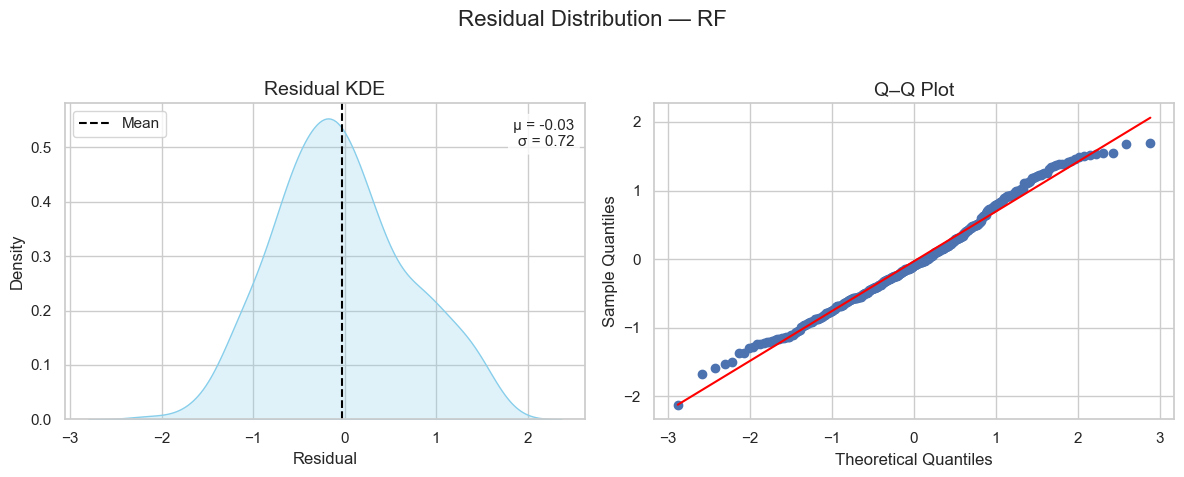

In [7]:
fig, axes = plot_residual_distribution(
    residuals_or_dict=residuals_test,
    title="Residual Distribution — RF",
    savepath=os.path.join(images_dir, "rf_residuals_distribution.png"),
)

# 2. Estimating the true distribution

This code is adopted from the last notebook as well. Estimating the parameters of constructing a normal distribution from a sample is straightforward analytically. Check [this](https://afnan-sultan.github.io/posts/2025/09/evaluation3/) blog for more details.

The best and the worst case scenarios are identified as three distributions.
1. The best case with µ = 0 and σ = lower bound
2. The worst case where the model underestimates the true value (µ = lower bound, σ = upper bound)
3. The worst case where the model overestimates the true value (µ = upper bound, σ = upper bound)

In [8]:
def _residual_ci_stats(residuals, alpha=0.05):
    r = np.asarray(pd.Series(residuals).dropna().values)
    if r.size == 0:
        raise ValueError("No residuals to plot.")
    n = len(r)
    x_bar = r.mean()
    s = r.std(ddof=1)
    sem = s / np.sqrt(n)
    t_crit = t.ppf(1 - alpha / 2, df=n - 1)
    ci_lower = x_bar - t_crit * sem
    ci_upper = x_bar + t_crit * sem

    df_ = n - 1
    s2 = np.var(r, ddof=1)
    chi2_lower = chi2.ppf(1 - alpha / 2, df_)
    chi2_upper = chi2.ppf(alpha / 2, df_)
    var_lower = (df_ * s2) / chi2_lower
    var_upper = (df_ * s2) / chi2_upper
    std_lower = np.sqrt(var_lower)
    std_upper = np.sqrt(var_upper)

    return {
        "n": n,
        "x_bar": x_bar,
        "ci_mean": (ci_lower, ci_upper),
        "std_CI": (std_lower, std_upper),
        "var_CI": (var_lower, var_upper),
        "min": r.min(),
        "max": r.max(),
        "residuals": r,
    }

def plot_distribution_estimation(
    residuals_or_dict,
    alpha=0.05,
    best_mean=0,
    title_single='Estimated Distributions',
    title_multi='Estimated Distributions — Best vs Worst Cases (per column)',
    savepath=None,
    show=True,
):
    """
    If residuals_or_dict is a single array:
      -> Plot ONE panel with KDE + best/worst curves for that model.
    If it's a dict {model_name: residuals}:
      -> Plot a 1x3 figure:
           [0] Best case (μ = best_mean, σ = std_lower(model))
           [1] Worst Under (μ = ci_lower(model), σ = std_upper(model))
           [2] Worst Over  (μ = ci_upper(model), σ = std_upper(model))
         In each subplot, overlay ALL models' curves for direct comparability.
    Returns
    -------
    For single array: (ci_dict, (fig, ax))
    For dict: (ci_by_model, (fig, axes[3]))
    """
    # ---- SINGLE MODEL ----
    if not isinstance(residuals_or_dict, dict):
        stats_dict = _residual_ci_stats(residuals_or_dict, alpha=alpha)

        # x-range based on residuals
        x_vals = np.linspace(stats_dict["min"] - 1, stats_dict["max"] + 1, 600)

        ci_lower, ci_upper = stats_dict["ci_mean"]
        std_lower, std_upper = stats_dict["std_CI"]

        best_pdf = norm.pdf(x_vals, loc=best_mean,  scale=std_lower)
        worst_low_pdf  = norm.pdf(x_vals, loc=ci_lower, scale=std_upper)
        worst_high_pdf = norm.pdf(x_vals, loc=ci_upper, scale=std_upper)

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        sns.kdeplot(stats_dict["residuals"], fill=True, color='skyblue', ax=ax, label="KDE")
        ax.plot(x_vals, best_pdf,       color='green',  linestyle='--', linewidth=2, label='Best')
        ax.plot(x_vals, worst_low_pdf,  color='orange', linestyle='-.', linewidth=2, label='Worst (Under)')
        ax.plot(x_vals, worst_high_pdf, color='red',    linestyle=':', linewidth=2, label='Worst (Over)')
        ax.axvline(stats_dict["x_bar"], color='skyblue', linestyle='--', linewidth=1.5, label='Mean')

        ax.set_title(title_single, fontsize=15)
        ax.set_xlabel('Residual', fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.legend(loc='upper left', fontsize=10)
        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=200, bbox_inches='tight')
        if show:
            plt.show()

        ci_dict = {
            "mean_CI": stats_dict["ci_mean"],
            "std_CI": stats_dict["std_CI"],
            "var_CI": stats_dict["var_CI"],
        }
        return ci_dict, (fig, ax)

    # ---- MULTI-MODEL (DICT) ----
    model_names = list(residuals_or_dict.keys())
    colors = sns.color_palette("tab10", n_colors=len(model_names))

    # compute per-model stats and global x-range
    per_model = {}
    mins, maxs = [], []
    for name in model_names:
        s = _residual_ci_stats(residuals_or_dict[name], alpha=alpha)
        per_model[name] = s
        mins.append(s["min"])
        maxs.append(s["max"])

    x_vals = np.linspace(min(mins) - 1, max(maxs) + 1, 600)

    # setup 1x3 figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=False)
    case_titles = ["Best Case", "Worst — Underestimating", "Worst — Overestimating"]

    # For each case, overlay all models
    for j, case in enumerate(["best", "worst_low", "worst_high"]):
        ax = axes[j]
        for color, name in zip(colors, model_names):
            s = per_model[name]
            ci_lower, ci_upper = s["ci_mean"]
            std_lower, std_upper = s["std_CI"]

            if case == "best":
                mu, sigma = best_mean, std_lower
            elif case == "worst_low":
                mu, sigma = ci_lower, std_upper
            else:  # "worst_high"
                mu, sigma = ci_upper, std_upper

            pdf = norm.pdf(x_vals, loc=mu, scale=sigma)
            ax.plot(x_vals, pdf, color=color, linewidth=2, label=name)

        ax.set_title(case_titles[j], fontsize=16)
        ax.set_xlabel('Residual', fontsize=12)
        if j == 0:
            ax.set_ylabel('Density', fontsize=12)

    # Put a shared legend outside (right)
    handles = [Line2D([], [], color=c, lw=2, label=n) for c, n in zip(colors, model_names)]
    fig.legend(handles=handles, labels=[n for n in model_names],
               loc='center right', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=14)
    fig.suptitle(title_multi, fontsize=16)
    fig.tight_layout(rect=[0, 0.03, 0.95, 0.95])  # leave room for legend

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
    if show:
        plt.show()

    ci_by_model = {
        name: {
            "mean_CI": per_model[name]["ci_mean"],
            "std_CI": per_model[name]["std_CI"],
            "var_CI": per_model[name]["var_CI"],
        }
        for name in model_names
    }
    return ci_by_model, (fig, axes)

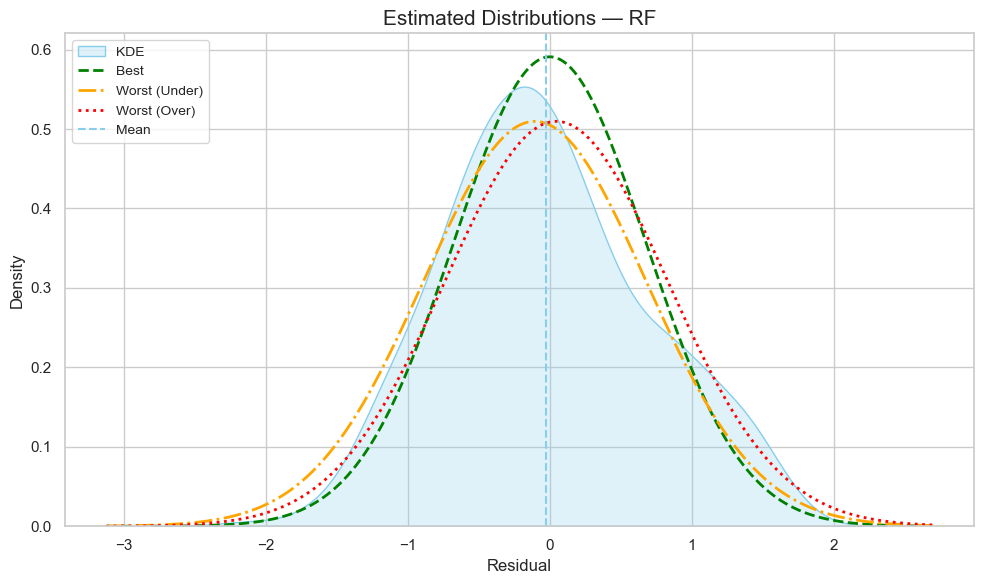

In [9]:
ci_rf, (fig, ax) = plot_distribution_estimation(
    residuals_or_dict=residuals_test,
    alpha=0.05,
    best_mean=0,
    title_single="Estimated Distributions — RF"
)


# 3. Data vs representation

A fun visualization to show the difference of what we, humans, see, and what a machine will end up seeing.

> Models do not see what we see. They see what **someone thinks** we see.

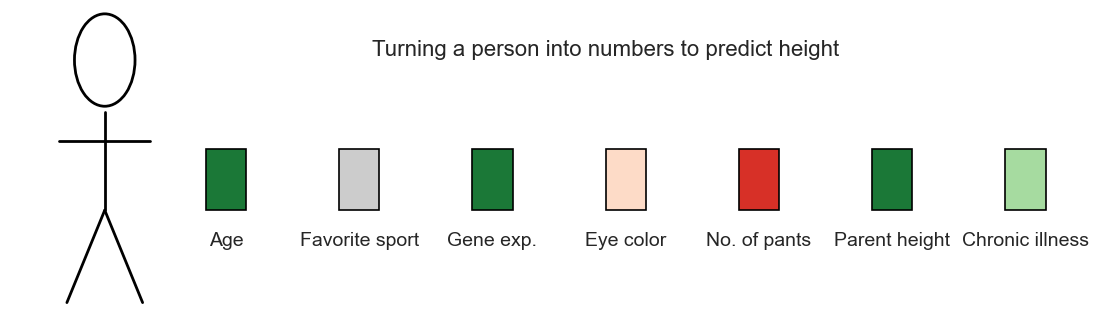

In [10]:
from matplotlib.patches import Circle, Rectangle

# --- EDIT YOUR FEATURES HERE ---
features = [
    "Age", "Favorite sport", "Gene exp.", "Eye color",
    "No. of pants", "Parent height", "Chronic illness"
]

# --- Define relevance categories ---
very_relevant = {"Parent height", "Gene exp.", "Nutrition", "Age", "Sex"}
mildly_relevant = {"Socioeconomic", "Chronic illness"}
little_relevant = {"Eye color", "Shoe size"}
not_relevant = {"No. of pants"}

# --- Map feature → color ---
def color_for(f):
    if f in very_relevant:
        return "#1b7837"   # deep green
    elif f in mildly_relevant:
        return "#a6dba0"   # soft green
    elif f in little_relevant:
        return "#fddbc7"   # pale orange
    elif f in not_relevant:
        return "#d73027"   # red-orange (avoid)
    else:
        return "#cccccc"   # neutral for unknown / uncategorized

colors = [color_for(f) for f in features]

# --- Draw stick person (with a circular head you can style) ---
def draw_stick_person(
    ax,
    center=(1.5, 2.0),
    scale=1.5,
    head_radius=0.42,                 # head size (relative to scale)
    head_edgecolor="black",
    head_facecolor="white",
    lw=2
):
    x, y = center
    # Head: clean circle
    ax.add_patch(Circle((x, y + 0.9 * scale), head_radius * scale,
                        fill=True, ec=head_edgecolor, fc=head_facecolor, lw=lw))
    # Body
    ax.plot([x, x], [y + 0.45 * scale, y - 0.4 * scale], lw=lw, color="black")
    # Arms
    ax.plot([x - 0.6 * scale, x + 0.6 * scale], [y + 0.2 * scale, y + 0.2 * scale], lw=lw, color="black")
    # Legs
    ax.plot([x, x - 0.5 * scale], [y - 0.4 * scale, y - 1.2 * scale], lw=lw, color="black")
    ax.plot([x, x + 0.5 * scale], [y - 0.4 * scale, y - 1.2 * scale], lw=lw, color="black")

# --- Layout parameters ---
square_size = 0.8
vertical_offset = 1.4
gap = square_size * 2.3  # dynamic spacing

# Compute positions dynamically:
start_x = 3.5
positions = start_x + np.arange(len(features)) * (square_size + gap)

# --- Create figure ---
fig_w = max(8, 2 * len(features))
fig, ax = plt.subplots(figsize=(fig_w, 4))
ax.set_axis_off()
ax.set_ylim(0, 4)

# Draw stick person with a prominent circular head
draw_stick_person(ax, head_facecolor="white", head_edgecolor="black", head_radius=0.4)

# Draw features
for x, feat, color in zip(positions, features, colors):
    ax.add_patch(Rectangle((x, vertical_offset), square_size, square_size, fc=color, ec="black", lw=1.2))
    ax.text(x + square_size / 2, vertical_offset - 0.28, feat, ha="center", va="top", fontsize=14)

# Title
ax.text((positions[0] + positions[-1]) / 2, 3.4,
        "Turning a person into numbers to predict height",
        ha="center", fontsize=16)

# --- Save safely (optional) ---
os.makedirs(images_dir, exist_ok=True)
plt.savefig(os.path.join(images_dir, "person.png"), dpi=200, bbox_inches="tight")

plt.show()


# 4. Model's worldview

Each model has a specific worldview based on the equation they are using for modeling.
- A linear regression (LR) model assumes that representation is relating to the data linearly and independent, so it fails when the data shows non-linear behavior
- A random forest (RF) model treats the data as separate regions and learns each region independently. This is helpful to capture different scenarios, but it will be helpful only in the specific regions it learned.
    - If the data was very representative and all regions are covered, then RF will generalize pretty nicely to new data.
    - If the data was limited to a specific region, RF will fail to extrapolate
- A simple neural network (NN) like the multi-layer perceptron (MLP) assumes that the data follows a smooth pattern. It can be simple or complex, but it has to be smooth.
    - If the data has abrupt jumps in outcome relative to the representation, an NN can struggle with capturing this trend correctly.
    - But if the data is indeed smooth, NN can generalize to new data better than RF because it learns the general function rather than the local regions.

The below code generate these three cases
1. Data and representation have linear relationship (All models perform well, although LR is the best)
2. Data and representation have non-smooth relationship (LR fails dramatically, MLP fails in the abrupt regions, and RF succeeds)
3. Data and representation have a smooth but non-linear relationship (LR fails dramatically, MLP and RF fit nicely. However, MLP has more parameters that can be tuned to fit even better)

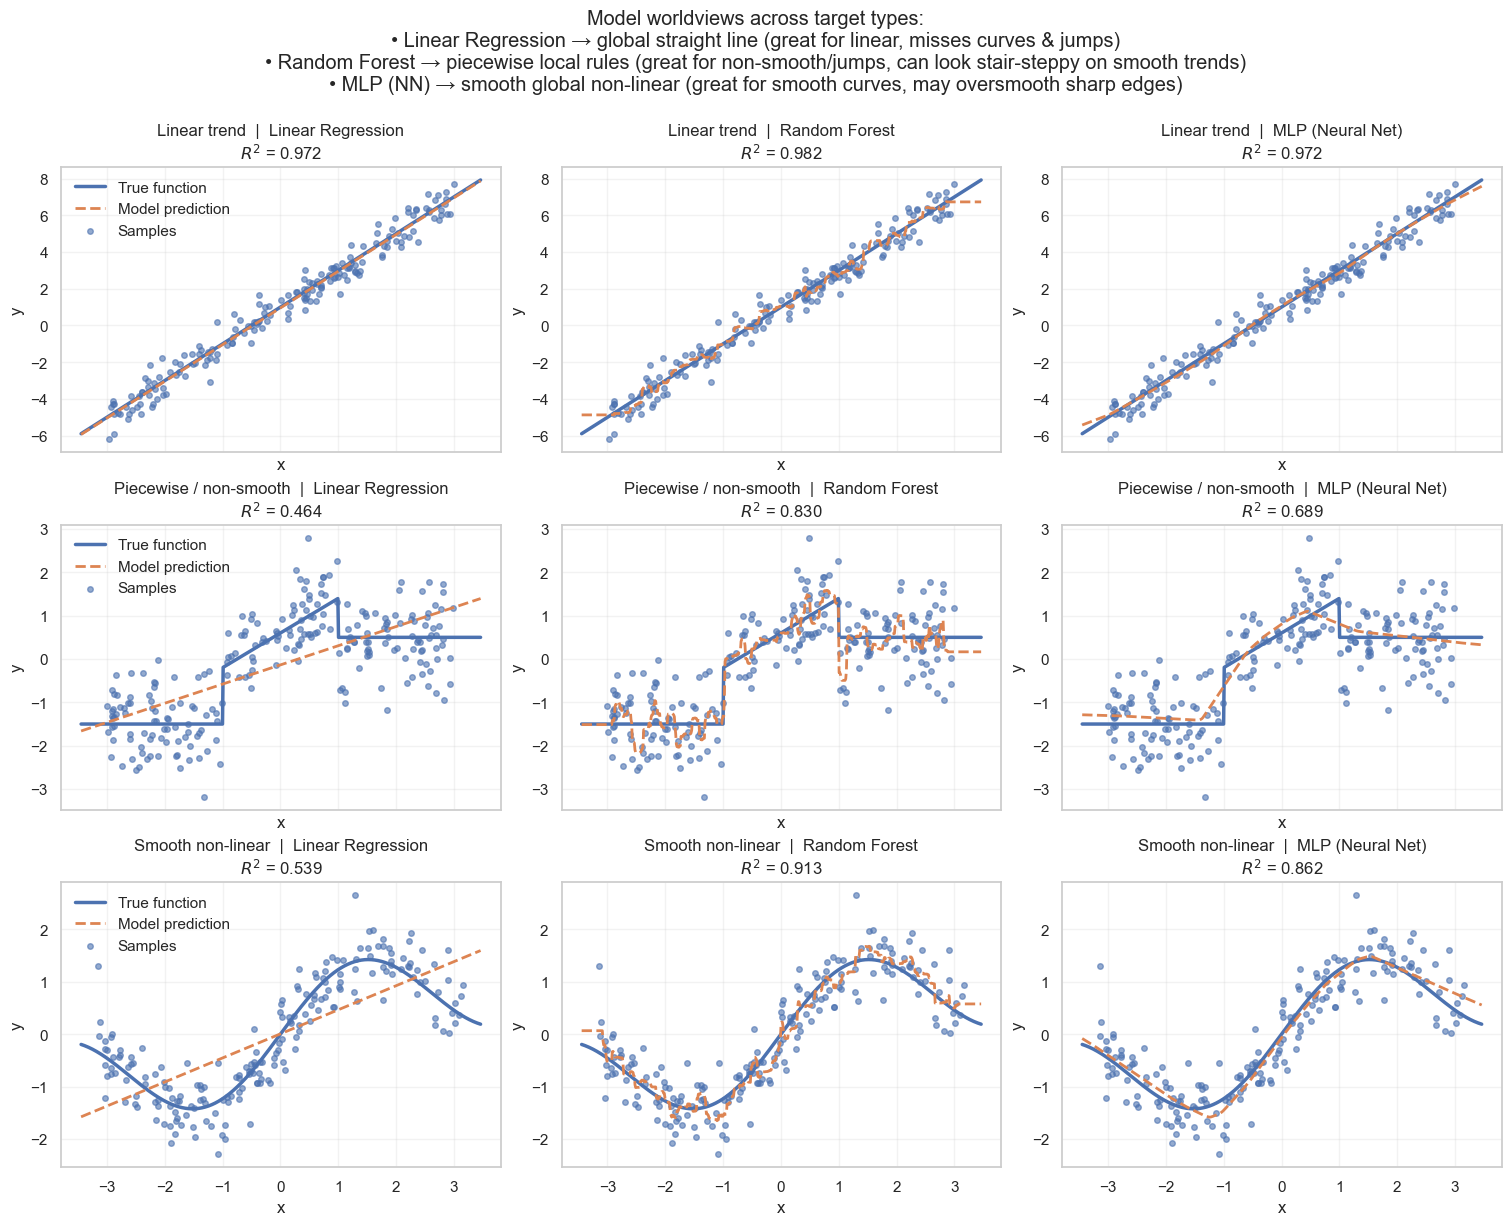

In [11]:
# LR vs RF vs MLP across three target types:
# 1) Linear, 2) Piecewise / non-smooth, 3) Smooth non-linear

from sklearn.utils import check_random_state
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings("ignore")  # quiet MLP convergence chatter

# -------------------------
# 1) Data generators
# -------------------------
def make_linear(n=180, rng=0, noise=0.6):
    rs = check_random_state(rng)
    X = rs.uniform(-3, 3, size=n)
    f = 2.0 * X + 1.0
    y = f + rs.normal(0, noise, size=n)
    return X.reshape(-1,1), y, (lambda t: 2.0*t + 1.0)

def make_piecewise(n=240, rng=1, noise=0.6):
    """
    Non-smooth with sharp boundaries (discontinuity + piecewise slopes):
      x < -1.0    : y = -1.5
      -1 <= x < 1 : y = 0.8*x + 0.6
      x >= 1.0    : y = 0.5
    """
    rs = check_random_state(rng)
    X = rs.uniform(-3, 3, size=n)
    X = np.sort(X)
    def f_true(t):
        t = np.asarray(t)
        left = t < -1
        mid  = (t >= -1) & (t < 1)
        right = t >= 1
        y = np.zeros_like(t, dtype=float)
        y[left] = -1.5
        y[mid]  = 0.8*t[mid] + 0.6
        y[right]= 0.5
        return y
    f = f_true(X)
    y = f + rs.normal(0, noise, size=n)
    return X.reshape(-1,1), y, f_true

def make_smooth_nonlinear(n=200, rng=2, noise=0.4):
    """
    Smooth but non-linear: y = sin(1.2x) + 0.3x
    """
    rs = check_random_state(rng)
    X = rs.uniform(-3.2, 3.2, size=n)
    X = np.sort(X)
    def f_true(t):
        t = np.asarray(t)
        return np.sin(1.2*t) + 0.3*t
    f = f_true(X)
    y = f + rs.normal(0, noise, size=n)
    return X.reshape(-1,1), y, f_true

# -------------------------
# 2) Models
# -------------------------
def get_models():
    # LR: simple global linear
    lr = LinearRegression()

    # RF: piecewise/local rules; min_samples_leaf tunes piecewise granularity
    rf = RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=3,
        random_state=0,
        n_jobs=-1
    )

    # MLP: smooth global non-linear; scale inputs to help training
    mlp = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 64),
            activation="relu",           # smooth; try 'relu' if you prefer piecewise-linear
            learning_rate_init=1e-3,
            alpha=1e-4,
            max_iter=5000,
            random_state=0
        ))
    ])
    return {
        "Linear Regression": lr,
        "Random Forest": rf,
        "MLP (Neural Net)": mlp
    }

# -------------------------
# 3) Fit, predict, visualize
# -------------------------
def fit_and_plot_row(axrow, dataset_name, X, y, f_true, models, xgrid):
    # Fit all models
    fitted = {}
    for name, mdl in models.items():
        mdl.fit(X, y)
        fitted[name] = mdl

    # Plot columns: LR | RF | MLP
    for col_idx, (name, mdl) in enumerate(fitted.items()):
        ax = axrow[col_idx]
        yhat_grid = mdl.predict(xgrid)

        # ground truth curve
        ax.plot(xgrid.ravel(), f_true(xgrid.ravel()), linewidth=2.5, label="True function")
        # model curve
        ax.plot(xgrid.ravel(), yhat_grid, linestyle="--", linewidth=2, label="Model prediction")
        # training samples
        ax.scatter(X[:,0], y, s=16, alpha=0.6, label="Samples")

        # R^2 on observed data
        r2 = r2_score(y, mdl.predict(X))
        ax.set_title(f"{dataset_name}  |  {name}\n$R^2$ = {r2:.3f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True, alpha=0.25)

    # put a shared legend just once (on first subplot of the row)
    handles, labels = axrow[0].get_legend_handles_labels()
    axrow[0].legend(handles, labels, loc="upper left", frameon=False)

# -------------------------
# 4) Run it
# -------------------------
models = get_models()

# Build datasets
X_lin, y_lin, f_lin = make_linear()
X_pw,  y_pw,  f_pw  = make_piecewise()
X_smo, y_smo, f_smo = make_smooth_nonlinear()

# Build a dense grid covering all datasets' domains
x_min = min(X_lin.min(), X_pw.min(), X_smo.min()) - 0.3
x_max = max(X_lin.max(), X_pw.max(), X_smo.max()) + 0.3
xgrid = np.linspace(x_min, x_max, 600).reshape(-1,1)

# Figure: 3 rows (datasets) x 3 cols (models)
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=True, sharey=False, constrained_layout=True)

fit_and_plot_row(axes[0], "Linear trend",          X_lin, y_lin, f_lin, models, xgrid)
fit_and_plot_row(axes[1], "Piecewise / non-smooth", X_pw,  y_pw,  f_pw,  models, xgrid)
fit_and_plot_row(axes[2], "Smooth non-linear",     X_smo, y_smo, f_smo, models, xgrid)

fig.suptitle(
    "Model worldviews across target types:\n"
    "• Linear Regression → global straight line (great for linear, misses curves & jumps)\n"
    "• Random Forest → piecewise local rules (great for non-smooth/jumps, can look stair-steppy on smooth trends)\n"
    "• MLP (NN) → smooth global non-linear (great for smooth curves, may oversmooth sharp edges)",
    y=1.1
)
plt.savefig(os.path.join(images_dir, "models_worldviews.png"))
plt.show()

## Playing with smoothness

Both RF and MLP have parameters to control the level of smoothness.
- One can force RF to behave smoothly by playing with the number of samples that end up in each region using the `min_samples_leaf` parameter. The more samples to be in a single region, the smoother the function is.
- One can force MLP to behave non smoothly by increasing the width (number of neurons) and depth (number of layers), as well as the activation function (here, we only experiment with RelU, which is already an intrinsically piecewise function).

The blow code shows the performance of each model with varying these parameters.

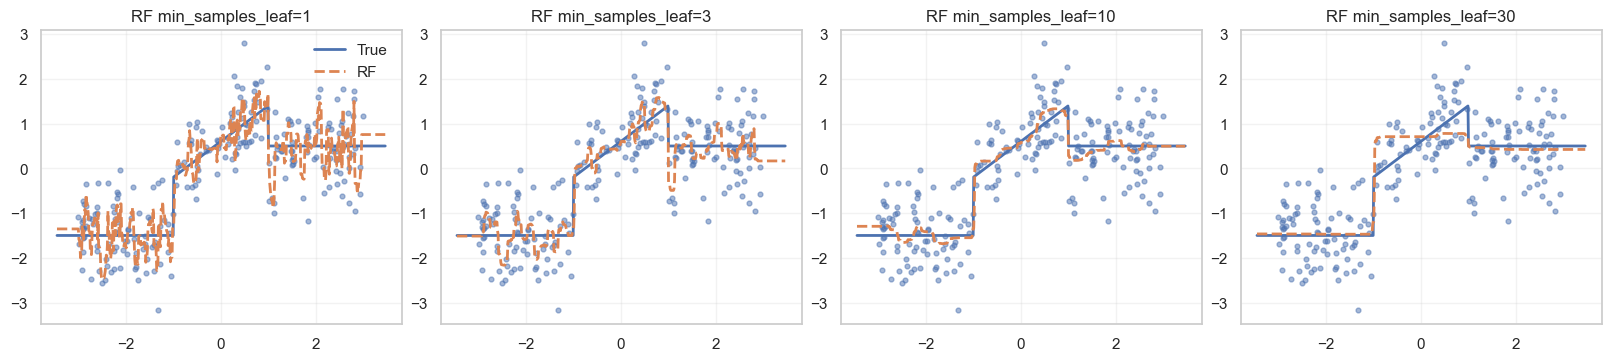

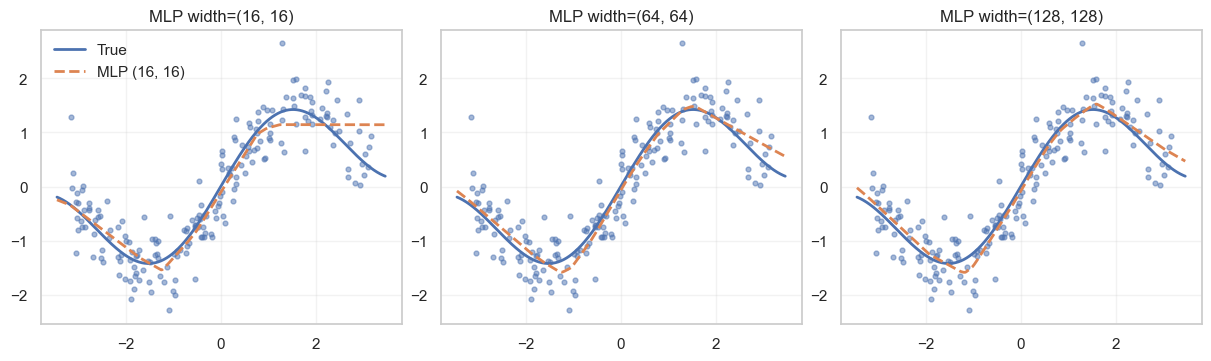

In [12]:
# -------------------------
# sensitivity knobs
# -------------------------
def rf_granularity_demo(X, y, f_true, xgrid, leaf_sizes=(1, 3, 10, 30)):
    fig, axs = plt.subplots(1, len(leaf_sizes), figsize=(4*len(leaf_sizes), 3.5), constrained_layout=True)
    for ax, leaf in zip(np.atleast_1d(axs), leaf_sizes):
        rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=leaf, random_state=0, n_jobs=-1)
        rf.fit(X, y)
        ax.plot(xgrid.ravel(), f_true(xgrid.ravel()), linewidth=2, label="True")
        ax.plot(xgrid.ravel(), rf.predict(xgrid), linestyle="--", linewidth=2, label="RF")
        ax.scatter(X[:,0], y, s=12, alpha=0.5)
        ax.set_title(f"RF min_samples_leaf={leaf}")
        ax.grid(True, alpha=0.25)
    axs[0].legend(frameon=False)
    plt.show()

def mlp_capacity_demo(X, y, f_true, xgrid, widths=((16,16),(64,64),(128,128))):
    fig, axs = plt.subplots(1, len(widths), figsize=(4*len(widths), 3.5), constrained_layout=True)
    for ax, w in zip(np.atleast_1d(axs), widths):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(hidden_layer_sizes=w, activation="relu",
                                 learning_rate_init=1e-3, alpha=1e-4,
                                 max_iter=5000, random_state=0))
        ])
        pipe.fit(X, y)
        ax.plot(xgrid.ravel(), f_true(xgrid.ravel()), linewidth=2, label="True")
        ax.plot(xgrid.ravel(), pipe.predict(xgrid), linestyle="--", linewidth=2, label=f"MLP {w}")
        ax.scatter(X[:,0], y, s=12, alpha=0.5)
        ax.set_title(f"MLP width={w}")
        ax.grid(True, alpha=0.25)
    axs[0].legend(frameon=False)
    plt.show()

# To explore:
rf_granularity_demo(X_pw, y_pw, f_pw, xgrid)       # shows RF's piecewise smoothing
mlp_capacity_demo(X_smo, y_smo, f_smo, xgrid)      # shows MLP capacity on smooth curves


# 5. Diagnosing the model

Now, we go back to the model that we trained for our dataset and representation, and we check homoscedasticity. As mentioned in the blog, homoscedasticity is a diagnostic plot that plots predictions against errors to ensure that the model is not biased.
- Homoscedasticity = random scatter plot around a horizontal line at `error = 0`
- Heteroscedasticity = any identifiable trend where the errors behave differently in different regions of the predictions.

The original plot simply plots errors vs. predictions, but I included a LOWESS smoothening line and a density contouring tools to help me spot the trend easier.
- If the trend is random, the LOWESS line will stay around the horizontal line at `error = 0` and the density contour will show symmetry above and below this line.

The trend shown below is more or less homoscedastic, even though it does not show a perfect horizontal LOWESS line and symmetric contour.
- With a somewhat small test set, perfect randomness is not expected. Where randomness is less prominent, it is likely sampling variability to the best of my knowledge.


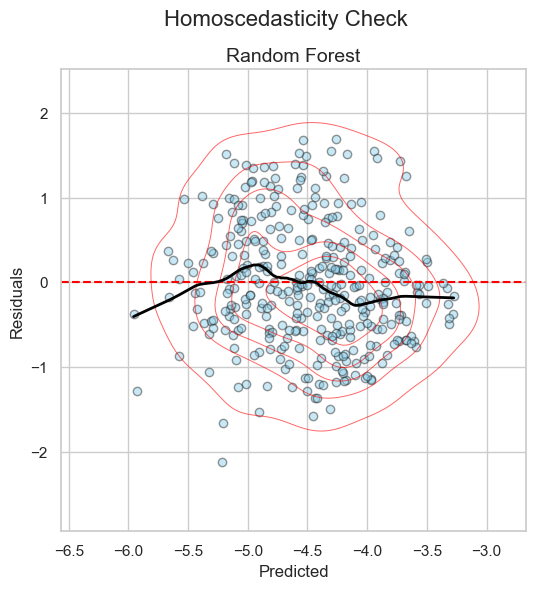

(<Figure size 600x600 with 1 Axes>,
 [<Axes: title={'center': 'Random Forest'}, xlabel='Predicted', ylabel='Residuals'>])

In [13]:
def plot_residuals_vs_predicted(models_pred_res_dict,
                                title="Residuals vs Predicted (Homoscedasticity Check)",
                                savepath=None,
                                sharey=True,
                                figsize=(6, 6),
                                add_lowess=True,
                                add_contour=True):
    """
    Plots residuals vs predicted for multiple models side-by-side in one row.
    Optionally overlays:
      - LOWESS smoothing line (trend detection)
      - 2D KDE contour (density structure)
    """

    n = len(models_pred_res_dict)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0] * n, figsize[1]),
                             sharey=sharey, sharex=False)

    if n == 1:
        axes = [axes]

    for ax, (model_name, (pred, res)) in zip(axes, models_pred_res_dict.items()):
        pred = np.asarray(pred)
        res = np.asarray(res)

        # Optional density contour (background structure)
        if add_contour:
            sns.kdeplot(x=pred, y=res, ax=ax, levels=6, color="red",
                        linewidths=0.7, alpha=0.6)

        # Scatter on top
        ax.scatter(pred, res, alpha=0.45, edgecolor='k', color='skyblue')

        # Zero-line
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

        # Optional LOWESS smoothing (trend)
        if add_lowess:
            smoothed = lowess(res, pred, frac=0.3, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", linewidth=2)

        # Labels
        ax.set_title(model_name, fontsize=14)
        ax.set_xlabel("Predicted", fontsize=12)

    axes[0].set_ylabel("Residuals", fontsize=12)

    fig.suptitle(title, fontsize=16)
    #fig.tight_layout(rect=[0, 0.03, 1, 0.93])

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig, axes


plot_residuals_vs_predicted(
    {
        "Random Forest": (y_pred_test, residuals_test),
    },
    title="Homoscedasticity Check",
    savepath=os.path.join(images_dir, "homoscedasticity_rf.png")
)



# 6. Simple inspection of representation vs. target relationship

We use the RDKit descriptors which include different types of feature. Some of these features are continuous (e.g., molecular weight), but some are only ordinal (e.g., count of aromatic rings), and some are count but with very few outcomes (e.g., count of a functional group).

To inspect the linearity correlation between each feature of these and the target (i.e., LogS), one needs to determine the appropriate correlation function. The below code uses some rules to choose between
1. Pearson: suitable when both variables are continuous.
2. Spearman rank correlation: suitable when the relationship is meaningful as ranking rather than linear alignment. Prominent when a variable is ordinal.
3. Kendall’s tau: used when a variable has only a few possible values or when there are many tied ranks, as it handles ties more robustly than Spearman.

All metrics can range between -1 and 1 where
- -1 = perfect inverse relationship (when one variable increases, the other decreases, and vice versa)
- 1 = perfect relationship (when one variable increases or decreases, the other does the same)
- 0 = there is no linear or monotonic relationship between the two variables

The below plot shows that the highest coefficient obtained from all metrics is only 0.26, which is very low. This means a model relying on linearity will not be able to handle these features well.

Top 6 features by |correlation| (auto-chosen method):
NumAromaticRings               kendall  r = -0.256
HallKierAlpha                  pearson  r = 0.255
BertzCT                        pearson  r = -0.230
MolLogP                        pearson  r = -0.190
fr_COO2                        kendall  r = 0.188
fr_COO                         kendall  r = 0.188


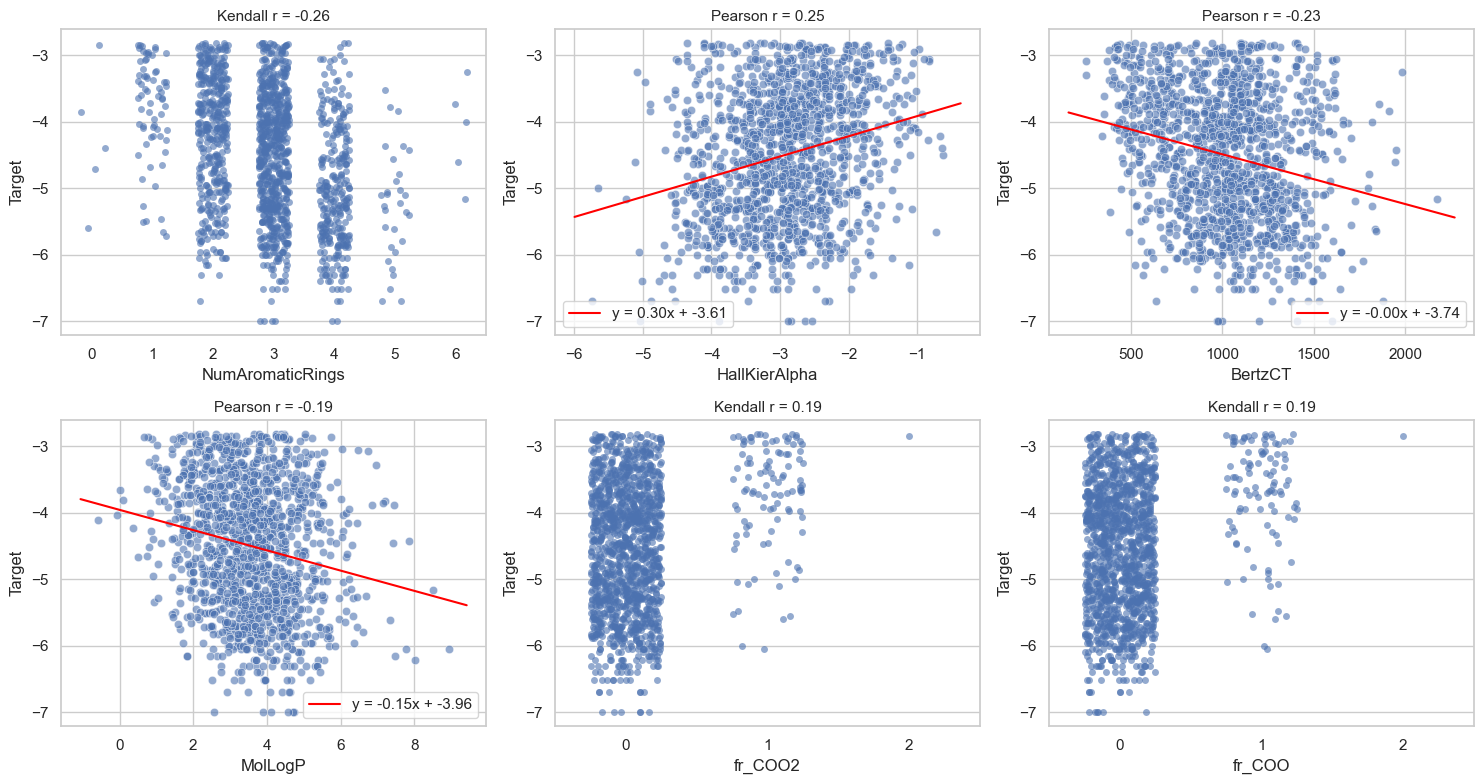

In [14]:
# ---- Data Alignment ----
X_aligned = X_train.loc[y_train.index]
num_highest_features = 6

# ---------------- Heuristics & Utilities ----------------
def is_integer_like(series, atol=1e-9):
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if s.empty:
        return False
    return np.all(np.isfinite(s)) and np.all(np.abs(s - np.round(s)) <= atol)

def ties_fraction(series):
    n = len(series)
    if n == 0:
        return 0.0
    nuniq = series.nunique(dropna=True)
    return 1.0 - (nuniq / n)

def outlier_rate_z(series, z=3.0):
    s = pd.to_numeric(series, errors="coerce")
    s = s[np.isfinite(s)]
    if s.empty:
        return 0.0
    mu, sd = s.mean(), s.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        return 0.0
    zscores = (s - mu) / sd
    return float((np.abs(zscores) > z).mean())

def choose_corr_method(x, y):
    """
    Decide among 'pearson', 'spearman', 'kendall' using simple, interpretable rules.
    """
    # Clean
    df = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                       'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if df.empty:
        return 'pearson'  # default fallback; will yield nan later

    x = df['x']
    y = df['y']

    nunique = x.nunique()
    ties_frac = ties_fraction(x)
    integer_like = is_integer_like(x)
    nonneg = (x >= 0).all()
    skew = float(pd.Series(x).skew()) if nunique > 2 else 0.0
    out_rate = outlier_rate_z(x)

    # Binary / two-level -> Pearson works fine (point-biserial)
    if nunique <= 2:
        return 'pearson'

    # Very few levels or many ties -> Kendall (τ-b handles ties best)
    if nunique <= 5 or ties_frac >= 0.50:
        return 'kendall'

    # Ordinal/few levels (<=10) or integer-like skewed counts -> Spearman
    if (integer_like and nunique <= 10) or (integer_like and nonneg and (skew > 1.0 or ties_frac > 0.10)):
        return 'spearman'

    # Continuous but with notable outliers -> Spearman
    if out_rate > 0.01:
        return 'spearman'

    # Default: continuous & roughly well-behaved -> Pearson
    return 'pearson'

def compute_corr(x, y, method):
    df = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                       'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if df.empty:
        return np.nan, np.nan
    x = df['x']; y = df['y']
    try:
        if method == 'pearson':
            r, p = stats.pearsonr(x, y)
        elif method == 'spearman':
            r, p = stats.spearmanr(x, y)
        elif method == 'kendall':
            r, p = stats.kendalltau(x, y, method='auto')
        else:
            r, p = np.nan, np.nan
        return float(r), float(p)
    except Exception:
        return np.nan, np.nan

# ------------- Score All Features (auto method selection) -------------
results = []
for col in X_aligned.columns:
    x = X_aligned[col]
    if x.isnull().all():
        continue
    method = choose_corr_method(x, y_train)
    r, p = compute_corr(x, y_train, method)
    if np.isfinite(r):
        results.append({'feature': col, 'r': r, 'abs_r': abs(r), 'p': p, 'method': method,
                        'nunique': x.nunique(), 'ties_frac': ties_fraction(x)})

corr_df = pd.DataFrame(results).sort_values('abs_r', ascending=False).reset_index(drop=True)

# ------------- Select Top Features -------------
top = corr_df.head(num_highest_features)

# ------------- Display Results -------------
print(f"Top {num_highest_features} features by |correlation| (auto-chosen method):")
for _, row in top.iterrows():
    print(f"{row['feature']:30} {row['method']:8} r = {row['r']:.3f}")

# ------------- Plotting -------------
num_plotted_features = min(6, len(top))
features_to_plot = top.iloc[:num_plotted_features]
n = len(features_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols)) if n > 0 else 1

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
if nrows * ncols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for i, (_, row) in enumerate(features_to_plot.iterrows()):
    ax = axes[i]
    feature = row['feature']
    method = row['method']
    score = row['r']

    x = X_train[feature]
    y = y_train

    # Decide scatter vs. strip by number of levels
    nunique = x.nunique()
    few_levels = nunique <= 10

    if few_levels:
        # Ordinal/few-level view
        sns.stripplot(x=x, y=y, ax=ax, jitter=0.25, alpha=0.6)
    else:
        # Continuous view
        sns.scatterplot(x=x, y=y, ax=ax, alpha=0.6)
        if method == 'pearson':
            # add simple OLS line for linear trend
            try:
                slope, intercept = np.polyfit(pd.to_numeric(x, errors='coerce'), pd.to_numeric(y, errors='coerce'), deg=1)
                x_vals = np.array(ax.get_xlim())
                y_vals = slope * x_vals + intercept
                ax.plot(x_vals, y_vals, color='red', label=f'y = {slope:.2f}x + {intercept:.2f}')
                ax.legend()
            except Exception:
                pass

    ax.set_title(f"{method.title()} r = {score:.2f}", fontsize=11)
    ax.set_xlabel(feature)
    ax.set_ylabel('Target')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join(images_dir, "linearity_check.png"))
plt.show()


# 7. Prepare features for the new models

Now, we are about to train linear regression (LR) and multi-layer perceptron (MLP) models. Unlike RF, which is more logic-dependant, these two models are heavily mathematics-dependant. They are based on equations that manipulate the numbers to figure out a relationship. And since math requires strict formatting, there are a couple of things to notice before playing with the math of these models.
1. The models have a single mathematical function they apply to all features, so, all features need to be on the same scale.
    - This is important so that a model does not assign a high weight to a feature just because the values range between 5 and 500, and ignore another because it varies between 0.1 and 0.8. The math does not proofread that these two features could be equally contributing to the prediction even if the scale is different.
    - Scaling transforms all features to live in the same range so that the math treats them equally and detects true signals.
2. However, scaling should not be done blindly. It makes a difference if the feature is continuous or ordinal. One has the meaning of continuity and the magnitude between two values matter, but another only cares about ranking (i.e., the magnitude does not have an intrinsic meaning).
3. All features must be present for a data point. If one feature is missing, one needs to find a way to anticipate it (imputing) or flag it. since the models perform multiplication operations, multiplying by a non-existing or infinity value will cause problems during training.

The below code prepares a report for my features to determine if they are binary (i.e., it has only two outcomes), ordinal (e.g., counts), or continuous. It also let me know if I have missing values in my data

In [15]:
import re

def _is_integer_like(series, atol=1e-9):
    s = series.dropna().astype(float)
    if s.empty:
        return False
    return np.all(np.isfinite(s)) and np.all(np.abs(s - np.round(s)) <= atol)

def _rdkit_name_hints(col):
    """
    RDKit descriptors that are typically counts (non-negative integers).
    Uses name patterns as hints, but we'll still validate via data.
    """
    patterns_count = [
        r"^Num", r"Count$", r"Count[A-Z]", r"^RingCount$", r"^HeavyAtomCount$",
        r"^NHOHCount$", r"^NOCount$", r"^MolWt$^$",  # keep MolWt out (typo guard)
        r"^NumValenceElectrons$", r"^NumRadicalElectrons$",
        r"^Num[A-Z][a-z]*Rings$", r"^HallKierAlpha$",  # alpha is float; will be data-checked
        r"^SlogP_VSA\d*$", r"^SMR_VSA\d*$",  # VSA are floats, data will override
        r"^TPSA$", r"^FractionCSP3$"  # these are floats; name hint alone is not binding
    ]
    for pat in patterns_count:
        if re.search(pat, col):
            return "maybe_count"
    return None

def audit_features(X_train: pd.DataFrame, X_test: pd.DataFrame, zero_inflation_threshold=0.5):
    """
    Produce a per-column report with:
      - inferred_type: {'binary','ordinal','count','continuous'}
      - missing/inf stats (train & test)
      - uniqueness, min/max, skewness
      - transform & imputation suggestions
    """
    # Align columns (should already match from your featurize function)
    assert list(X_train.columns) == list(X_test.columns), "Train/Test columns differ."

    rows = []
    for col in X_train.columns:
        s_tr = X_train[col]
        s_te = X_test[col]

        # Basic stats
        n_tr = len(s_tr)
        n_te = len(s_te)

        n_missing_tr = int(s_tr.isna().sum())
        n_missing_te = int(s_te.isna().sum())
        pct_missing_tr = n_missing_tr / max(n_tr, 1)
        pct_missing_te = n_missing_te / max(n_te, 1)

        # treat +/-inf as missing for model purposes
        n_inf_tr = int(np.isinf(s_tr).sum()) if np.issubdtype(s_tr.dtype, np.number) else 0
        n_inf_te = int(np.isinf(s_te).sum()) if np.issubdtype(s_te.dtype, np.number) else 0

        # numeric guard
        numeric = np.issubdtype(s_tr.dtype, np.number)

        unique_tr = s_tr.dropna().unique()
        n_unique_tr = len(unique_tr)

        # integer-like & non-negative checks on train
        integer_like = _is_integer_like(s_tr)
        non_negative = (s_tr.dropna() >= 0).all() if numeric else False

        # zero fraction (on train)
        zero_frac = float((s_tr == 0).sum()) / max(n_tr, 1) if numeric else np.nan

        # min/max/skew
        s_tr_num = s_tr.dropna().astype(float) if numeric else pd.Series([], dtype=float)
        min_v = float(s_tr_num.min()) if not s_tr_num.empty else np.nan
        max_v = float(s_tr_num.max()) if not s_tr_num.empty else np.nan
        skew = float(s_tr_num.skew()) if not s_tr_num.empty else np.nan

        # Infer raw type (heuristics combining name hints + data)
        name_hint = _rdkit_name_hints(col)

        inferred = "continuous"
        # Binary
        if numeric and n_unique_tr <= 2 and integer_like and non_negative:
            inferred = "binary"
        # Ordinal (few levels, integer-like)
        elif numeric and integer_like and n_unique_tr <= 10:
            inferred = "ordinal"
        # Counts (integer-like, non-negative, potentially many unique)
        elif numeric and integer_like and non_negative:
            inferred = "count"
        # If name suggests count but the data aren't exact integers (due to float casts),
        # allow "count" if values are within small tol of integers AND non-negative.
        elif numeric and (name_hint == "maybe_count") and non_negative and _is_integer_like(np.round(s_tr, 6)):
            inferred = "count"
        else:
            inferred = "continuous"

        # Suggestions
        needs_impute = (n_missing_tr + n_inf_tr) > 0 or (n_missing_te + n_inf_te) > 0

        transform = None
        if inferred == "count":
            # advise log1p if skewed or wide range
            if (skew is not np.nan and skew > 1.0) or (np.isfinite(min_v) and np.isfinite(max_v) and (max_v - min_v) > 50):
                transform = "log1p_then_standardize"
            else:
                transform = "standardize"
        elif inferred in ("continuous",):
            transform = "standardize"
        elif inferred in ("ordinal","binary"):
            transform = "none_or_standardize_if_needed"

        impute = None
        if needs_impute:
            if inferred in ("count", "ordinal", "binary"):
                # for counts/ordinal/binary, prefer median or special code + indicator
                impute = "median_or_special_code(+missing_indicator)"
            else:
                impute = "median(+missing_indicator)"

        # Zero-inflation flag
        zero_inflated = (inferred == "count") and (zero_frac >= zero_inflation_threshold)

        rows.append({
            "column": col,
            "dtype": str(X_train[col].dtype),
            "inferred_type": inferred,
            "n_unique_train": n_unique_tr,
            "min": min_v, "max": max_v, "skew": skew,
            "integer_like": bool(integer_like),
            "non_negative": bool(non_negative),
            "zero_fraction_train": zero_frac,
            "zero_inflated": bool(zero_inflated),
            "missing_train": n_missing_tr,
            "missing_test": n_missing_te,
            "inf_train": n_inf_tr,
            "inf_test": n_inf_te,
            "pct_missing_train": pct_missing_tr,
            "pct_missing_test": pct_missing_te,
            "transform_suggestion": transform,
            "imputation_suggestion": impute,
        })

    report = pd.DataFrame(rows).sort_values(
        ["inferred_type", "pct_missing_train", "column"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    # Handy index lists for building pipelines
    cols_binary   = report.query("inferred_type == 'binary'")["column"].tolist()
    cols_ordinal  = report.query("inferred_type == 'ordinal'")["column"].tolist()
    cols_count    = report.query("inferred_type == 'count'")["column"].tolist()
    cols_cont     = report.query("inferred_type == 'continuous'")["column"].tolist()

    summary = {
        "n_columns": X_train.shape[1],
        "binary": len(cols_binary),
        "ordinal": len(cols_ordinal),
        "count": len(cols_count),
        "continuous": len(cols_cont),
        "any_missing_or_inf": bool((report["missing_train"]+report["missing_test"]+report["inf_train"]+report["inf_test"]).sum() > 0)
    }

    return report, {"binary": cols_binary, "ordinal": cols_ordinal, "count": cols_count, "continuous": cols_cont}, summary


In [16]:
report, col_groups, summary = audit_features(X_train, X_test)
print(summary)
display(report.head(5))  # or print(report.to_string(max_rows=40))

{'n_columns': 193, 'binary': 22, 'ordinal': 62, 'count': 6, 'continuous': 103, 'any_missing_or_inf': False}


,column,dtype,inferred_type,n_unique_train,min,max,skew,integer_like,non_negative,zero_fraction_train,zero_inflated,missing_train,missing_test,inf_train,inf_test,pct_missing_train,pct_missing_test,transform_suggestion,imputation_suggestion
0,fr_Ar_COO,int64,binary,2,0.0,1.0,4.973651,True,True,0.963830,False,0,0,0,0,0.0,0.0,none_or_standardize_if_needed,None
1,fr_C_S,int64,binary,2,0.0,1.0,26.523534,True,True,0.998582,False,0,0,0,0,0.0,0.0,none_or_standardize_if_needed,None
2,fr_SH,int64,binary,2,0.0,1.0,37.549967,True,True,0.999291,False,0,0,0,0,0.0,0.0,none_or_standardize_if_needed,None
3,fr_aldehyde,int64,binary,2,0.0,1.0,26.523534,True,True,0.998582,False,0,0,0,0,0.0,0.0,none_or_standardize_if_needed,None
4,fr_amidine,int64,binary,2,0.0,1.0,8.689469,True,True,0.987234,False,0,0,0,0,0.0,0.0,none_or_standardize_if_needed,None


In [ ]:
import os
import json
import joblib

def save_feature_types(report, col_groups, summary, save_dir, stem="feature_types"):
    """
    Saves:
      - report (CSV)
      - col_groups (joblib + json)
      - summary (json)
    """
    os.makedirs(save_dir, exist_ok=True)

    report_path = os.path.join(save_dir, f"{stem}_report.csv")
    groups_joblib_path = os.path.join(save_dir, f"{stem}_col_groups.joblib")
    groups_json_path = os.path.join(save_dir, f"{stem}_col_groups.json")
    summary_path = os.path.join(save_dir, f"{stem}_summary.json")

    report.to_csv(report_path, index=False)
    joblib.dump(col_groups, groups_joblib_path)

    with open(groups_json_path, "w") as f:
        json.dump(col_groups, f, indent=2)

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    return {
        "report_csv": report_path,
        "col_groups_joblib": groups_joblib_path,
        "col_groups_json": groups_json_path,
        "summary_json": summary_path,
    }

# Example:
paths = save_feature_types(
    report=report,
    col_groups=col_groups,
    summary=summary,
    save_dir=images_dir,           # or any folder you like
    stem="rdkit_feature_types"
)
paths

## Preprocessing

The report showed me that there are no missing or weird values in my data, so, I need not worry about imputing. But I need to make sure that I scale things correctly.

ChatGPT has been my companion in preparing and preprocessing the features, and I am now too tired of understanding the details of the preprocessing. So, be my guest if you want to understand more. 😌

The below code scales (or does not scale) each feature type as fit, then uses the sklearn Pipeline function to automatically pass a feature space to the preprocessor before using the model.

We train and test using the same rational as for RF.

### Tuning the MLP

Now, the moment one steps to the world of neural network (NN), one is really in a headache to tune so many parameters. I am not an expert in how NNs work yet, and when I make a choice about a hyperparameter, I do not have an intuition on how it would affect my training.

And I truly believe that hyperparameter tuning should be driven by concrete understanding of the data, the model, and the intuitive effect of these parameters in my specific case.

I mainly experimented with the depth and width of the network because I know that these two parameters allow for more interactions between the features to be taken into consideration. So, I would increase them to see if more parameters would lead to better performance, but it did not.

The other parameter is the activation function. I use `relu` because I knew after preliminary inspection that it is a piecewise function and can fit my data better. A function like `tanh` is a smooth function, and it was causing the model to perform worse (because it was not suitable).

The learning rate, stopping schedule, optimizer, etc. They are all things that I know their abstract meaning, but I do not know their empirical and intuitive effect on my data.

So, purely out of frustration, I really dislike treating neural networks as if they are the solution to our problems while ignoring the nuances and complexities it comes with.

> NNs might be the solution to our problem, but this might never be proven if we succumb to the "black box" dogma just because we became fragile in the face of complexity.


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

preprocess = ColumnTransformer([
    ("cont", StandardScaler(), col_groups["continuous"]),
    ("count_log", Pipeline([
        ("log1p", FunctionTransformer(np.log1p, validate=False)),
        ("scale", StandardScaler())
    ]), col_groups["count"]),
    ("ordinal", StandardScaler(), col_groups["ordinal"]),
    ("binary", "passthrough", col_groups["binary"])
])

# Linear Regression
lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])
lr.fit(X_train, y_train)

y_pred_train_lr = lr.predict(X_train)
y_pred_test_lr  = lr.predict(X_test)

residuals_train_lr = y_pred_train_lr - y_train
residuals_test_lr  = y_pred_test_lr  - y_test

# MLP
mlp = Pipeline([
    ("preprocess", preprocess),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate="adaptive",
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
    ))
])
mlp.fit(X_train, y_train)

y_pred_train_mlp = mlp.predict(X_train)
y_pred_test_mlp  = mlp.predict(X_test)

residuals_train_mlp = y_pred_train_mlp - y_train
residuals_test_mlp  = y_pred_test_mlp  - y_test

We now plot the distribution and the Q-Q normally check of the two models. They also show a normality tendancy as shown for RF.

I am personally relieved because this means that I only need to estimate µ and σ for each distribution, and the different distributions will be safely comparable.

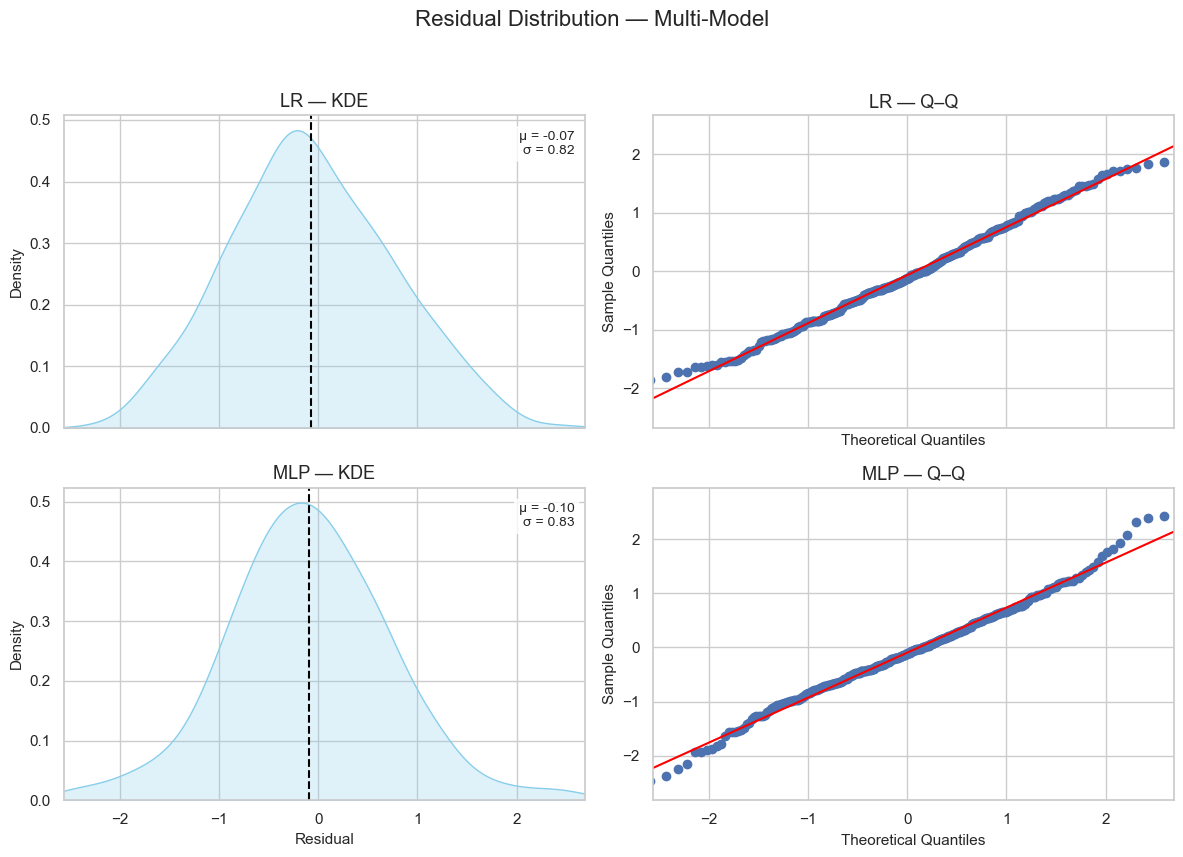

In [18]:
fig, axes = plot_residual_distribution(
    residuals_or_dict={
        "LR": residuals_test_lr,
        "MLP": residuals_test_mlp,
    },
    title="Residual Distribution — Multi-Model",
    sharex=True,  # same residual x-scale per column
    row_height=4.5,
    savepath=os.path.join(images_dir, "models_residuals_distribution.png")
)


Here, I show three plots for the three models comparing the best and worst case scenarios.

The RF model seems to show the more stable distribution among the three models. However, this is probably not significant. The distributions look so much close to each other, and any significance test will probably conclude that these models ore or less perform similarly.

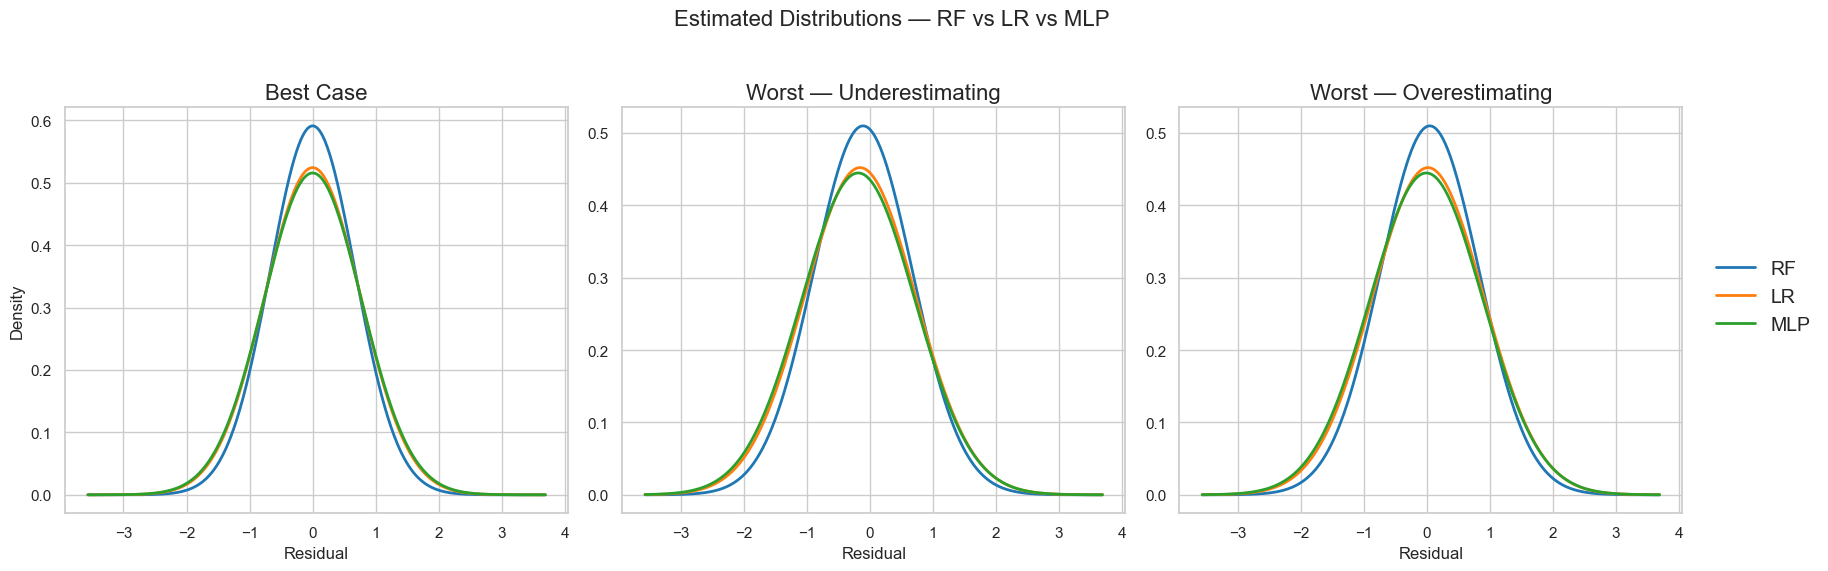

In [19]:
ci_by_model, (fig, axes) = plot_distribution_estimation(
    residuals_or_dict={
        "RF": residuals_test,
        "LR": residuals_test_lr,
        "MLP": residuals_test_mlp,
    },
    alpha=0.05,
    best_mean=0,
    title_multi="Estimated Distributions — RF vs LR vs MLP",
    savepath=os.path.join(images_dir, "models_residuals_comparison.png")
)


Now, despite the performance would show a more or less similar performance, the homoscedasticity check confirms that RF should be the superior model because it is the one with minimal systematic bias.

In the blog, I tried to understand why RF was the most suitable model for my data, and listening to the three models together made me point my fingers to the data.

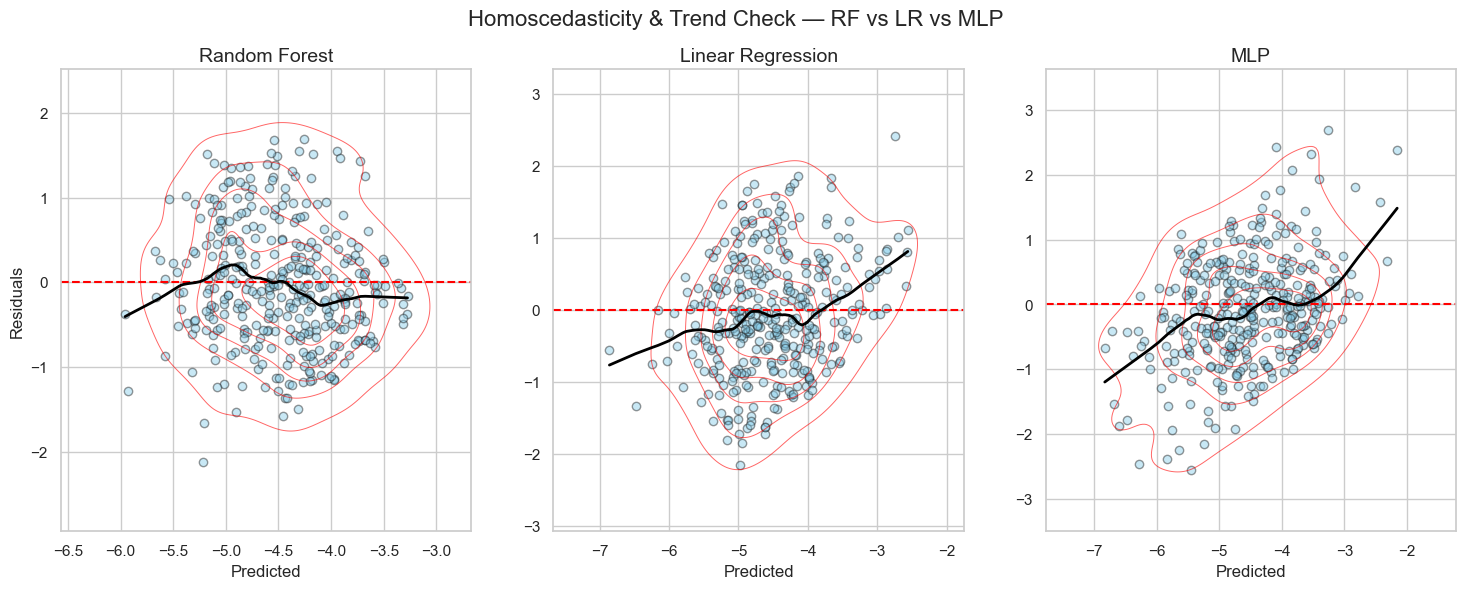

(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: title={'center': 'Random Forest'}, xlabel='Predicted', ylabel='Residuals'>,
        <Axes: title={'center': 'Linear Regression'}, xlabel='Predicted'>,
        <Axes: title={'center': 'MLP'}, xlabel='Predicted'>], dtype=object))

In [20]:
plot_residuals_vs_predicted(
    {
        "Random Forest": (y_pred_test, residuals_test),
        "Linear Regression": (y_pred_test_lr, residuals_test_lr),
        "MLP": (y_pred_test_mlp, residuals_test_mlp),
    },
    sharey=False,
    title="Homoscedasticity & Trend Check — RF vs LR vs MLP",
    add_lowess=True,
    add_contour=True,  # try False if the background is too busy
    savepath=os.path.join(images_dir, "models_homoscedasticity_check.png")
)


# Let's recap

- **Normality isn’t universal:** it mainly matters for linear regression and significance testing. However, it helps a lot when the errors do follow a normal distribution.
  - One can infer the distribution shape if they have a medium-size sample
- Assessing a model’s performance starts **before** comparison — it begins with checking whether the setup itself makes sense.
  - The data, representation, and model must be in harmony before their outcomes can be trusted.
- Each model offers a **different worldview**: linear, piecewise, or smooth and continuous.
  - Listening to how they each fail or succeed reveals more about the **data** than about the models themselves.
- The goal is not to crown a “best performer,” but to **learn what the performance means**.
  - to understand where the signal ends, where the noise begins, and what the model is really trying to say.
